In [ ]:
#pip install aotools

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, IntSlider
from tabulate import tabulate
from aotools.turbulence.phasescreen import ft_phase_screen

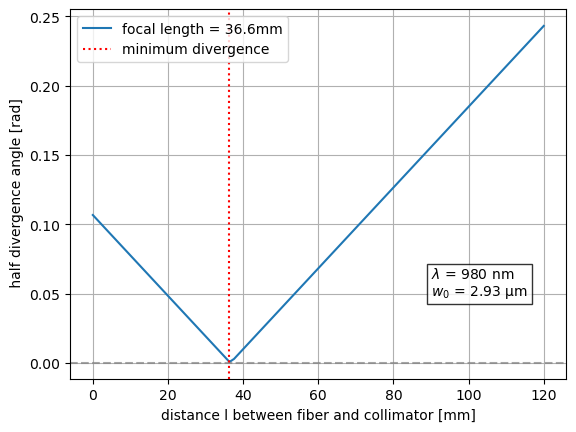

theta(l=60 mm) = 0.06641848280193448


In [3]:
l=np.linspace(0, 120, 100) #length of free space mm
wavelength= 980e-6 #mm MFD only defined for that length
F=36.6 #focal length collimator in mm
MFD= (6.4+5.3)/2 *1e-3 #mode field diamter 5,3-6,4 mm

w0= MFD/2 # apparently for aingle mode fibers
theta_0 = wavelength/ (np.pi * F * w0) * np.sqrt((F - l)**2 + (np.pi * w0**2 / wavelength)**2)


l_min= l[np.argmin(theta_0)]

fig, ax = plt.subplots()

ax.plot(l, theta_0, label='focal length = 36.6mm')
ax.set_xlabel('distance l between fiber and collimator [mm]')
ax.set_ylabel(' half divergence angle [rad]')
plt.axhline(y=0, alpha=0.7, c='grey',linestyle='--')
plt.axvline(l_min, linestyle=':', color='red', label='minimum divergence')
ax.grid()
ax.legend()



info_text = (
    f"$\lambda$ = {wavelength*1e6:.0f} nm\n"
    f"$w_0$ = {w0*1e3:.2f} µm"
)

ax.text(
    90, 0.07, info_text,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(boxstyle="square", facecolor="white", alpha=0.8)
)

plt.grid(True)
plt.show()
#plt.savefig("hdivergence_distance.pdf", format="pdf")
plt.show()
print("theta(l=60 mm) =", theta_0[np.argmin(np.abs(l-60))])

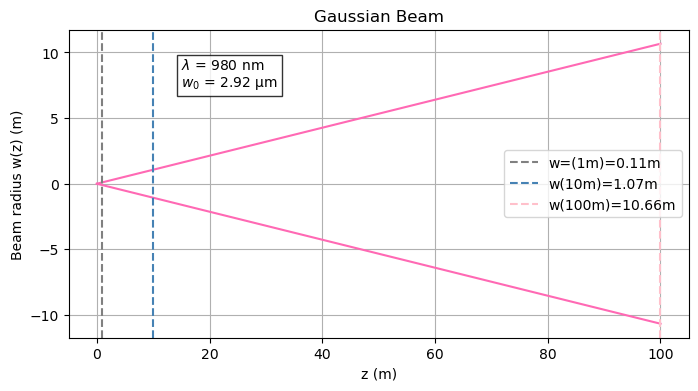

In [4]:
z = np.linspace(0, 100, 500) #0 bis 10 meter
wavelength= 980e-9 #mm MFD only defined for that length
F=36.6*1e-3 #focal length collimator in mm
MFD= (6.4+5.3)/2 *1e-6 #mode field diamter 5,3-6,4 mm

w0= MFD/2 # apparently for single mode fibers

zR = np.pi * w0**2 / wavelength

# Beamradius
w = w0 * np.sqrt(1 + (z/zR)**2)

idx_1m = np.argmin(np.abs(z - 1))
idx_10m = np.argmin(np.abs(z - 10))
idx_100m = np.argmin(np.abs(z - 100))

# Plot
plt.figure(figsize=(8,4))
plt.plot(z,  w, color='hotpink')
plt.plot(z, -w,  color='hotpink')
#plt.axvline(0, color='gray', linestyle='--')
plt.title("Gaussian Beam")
plt.xlabel("z (m)")
plt.ylabel("Beam radius w(z) (m)")
plt.axvline(1, color='gray', linestyle='--', label= f"w=(1m)={w[idx_1m]:.2f}m")
plt.axvline(10, color='steelblue', linestyle='--', label= f"w(10m)={w[idx_10m]:.2f}m")
plt.axvline(100, color='pink', linestyle='--', label= f"w(100m)={w[idx_100m]:.2f}m")
plt.grid(True)
plt.legend(loc='center right')

info_text = (
    f"$\lambda$ = {wavelength*1e9:.0f} nm\n"
    f"$w_0$ = {w0*1e6:.2f} µm"
)

plt.text(
    15, 7, info_text,
    fontsize=10,
    verticalalignment='bottom',
    bbox=dict(boxstyle="square", facecolor="white", alpha=0.8)
)

#plt.savefig("beam_waist_for_1_10_100m.pdf", format="pdf")
plt.show()

In [5]:
wavelength= 980e-9 #mm MFD only defined for that length
F=36.6*1e-3 #focal length collimator in mm
MFD= (6.4+5.3)/2 *1e-6 #mode field diamter 5,3-6,4 micros

z = np.linspace(0, 100, 500) #0 bis 10 meter
w0= MFD/2 # apparently for single mode fibers


def plot_and_table(l_mm):
    l = l_mm / 1000
    w0_n = F*w0 / np.sqrt((F-l)**2 + (np.pi*w0**2/wavelength)**2) #new one

    zR = np.pi * w0**2 / wavelength
    zR_n = np.pi * w0_n**2 / wavelength

    w = w0 * np.sqrt(1 + (z/zR)**2)
    w_n= w0_n * np.sqrt(1 + (z/zR_n)**2)

    idx_1m = np.argmin(np.abs(z - 1))
    idx_10m = np.argmin(np.abs(z - 10))
    idx_100m = np.argmin(np.abs(z - 100))

    theta = wavelength / (np.pi * w0)
    theta_n = wavelength / (np.pi * w0_n)

    # Plot
    plt.figure(figsize=(8,4))
    plt.plot(z,  w, color='hotpink', label='beam with w0')
    plt.plot(z, -w,  color='hotpink')

    plt.plot(z,  w_n, color='darkred', label='beam with w0_n (new)')
    plt.plot(z, -w_n,  color='darkred')

    plt.title("Gaussian Beam")
    plt.xlabel("z (m)")
    plt.ylabel("Beam radius w(z) (m)")
    plt.axvline(1, color='gray', linestyle='--', label= f"z=1m")
    plt.axvline(10, color='steelblue', linestyle='--', label= f"z=10m")
    plt.axvline(100, color='darkgreen', linestyle='--', label= f"z=100m")
    plt.grid(True)
    plt.legend(loc='best')

    #plt.savefig("beam_waist_for_1_10_100m.pdf", format="pdf")
    plt.show()

    data2 = [
        [f"{wavelength*1e9:.2f}", f"{F*1e3:.2f}", f"{l_mm:.2f}", f"{w0:.2e}", f"{w0_n:.2e}", f"{theta*1e3:.2f}", f"{theta_n*1e3:.2f}"]]
    header2 = ["wavelength [nm]", "F [mm]", "l [mm]", "w0 [m]", "w0' [m]", "theta [mrad]", "theta' [mrad]"]

    print(tabulate(data2, headers=header2, tablefmt="grid"))

    data1 = [
        ["1 m",   f"{w[idx_1m]:.4f}",   f"{w_n[idx_1m]:.4f}"],
        ["10 m",  f"{w[idx_10m]:.4f}",  f"{w_n[idx_10m]:.4f}"],
        ["100 m", f"{w[idx_100m]:.4f}", f"{w_n[idx_100m]:.4f}"]
    ]
    header1 = ["z", "w(z) [m]", "w'(z) [m]"]

    print(tabulate(data1, headers=header1, tablefmt="grid"))


interact(
    plot_and_table,
    l_mm=FloatSlider(
        value=40,
        min=0,
        max=120,
        step=1,
        description="l (mm)"
    )
)



interactive(children=(FloatSlider(value=40.0, description='l (mm)', max=120.0, step=1.0), Output()), _dom_clas…

<function __main__.plot_and_table(l_mm)>

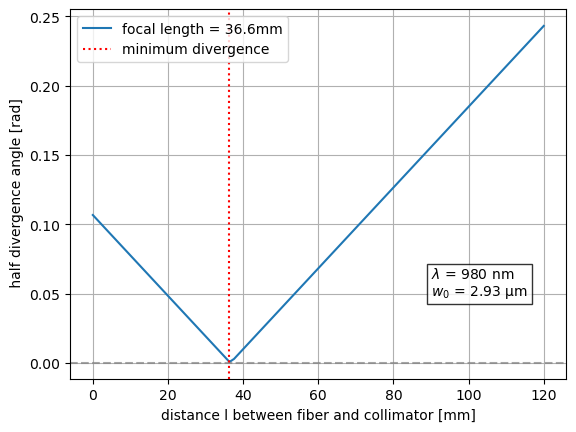

theta(l=60 mm) = 0.06641848280193448


In [6]:
#now with varaible focal length 
l=np.linspace(0, 120, 100) #length of free space mm
wavelength= 980e-6 #mm MFD only defined for that length
F=36.6 #focal length collimator in mm
MFD= (6.4+5.3)/2 *1e-3 #mode field diamter 5,3-6,4 mm

w0= MFD/2 # apparently for aingle mode fibers
theta_0 = wavelength/ (np.pi * F * w0) * np.sqrt((F - l)**2 + (np.pi * w0**2 / wavelength)**2)


l_min= l[np.argmin(theta_0)]

fig, ax = plt.subplots()

ax.plot(l, theta_0, label='focal length = 36.6mm')
ax.set_xlabel('distance l between fiber and collimator [mm]')
ax.set_ylabel(' half divergence angle [rad]')
plt.axhline(y=0, alpha=0.7, c='grey',linestyle='--')
plt.axvline(l_min, linestyle=':', color='red', label='minimum divergence')
ax.grid()
ax.legend()



info_text = (
    f"$\lambda$ = {wavelength*1e6:.0f} nm\n"
    f"$w_0$ = {w0*1e3:.2f} µm"
)

ax.text(
    90, 0.07, info_text,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(boxstyle="square", facecolor="white", alpha=0.8)
)

plt.grid(True)
plt.show()
#plt.savefig("hdivergence_distance.pdf", format="pdf")
plt.show()
print("theta(l=60 mm) =", theta_0[np.argmin(np.abs(l-60))])

In [9]:
wavelength= 980e-9 #mm MFD only defined for that length
F_1=36.6*1e-3 #focal length collimator in mm
n=1
MFD= (6.4+5.3)/2 *1e-6 #mode field diamter 5,3-6,4 micros

z = np.linspace(0, 100, 500) #0 bis 10 meter
w0= MFD/2 # apparently for single mode fibers

def plot_and_table(l_mm, F_2_mm, d_mm):
    l = l_mm / 1000
    F_2= F_2_mm/1000
    d=d_mm/1000


    def focal_lens_system(F_2, d):
        reciprocal_focal_eff=1/F_1+1/F_2-d/(F_1*F_2*n) #def d und F2 fehlt
        return 1/reciprocal_focal_eff

    F_eff=focal_lens_system(F_2, d)

    w0_n = F_eff*w0 / np.sqrt((F_eff-l)**2 + (np.pi*w0**2/wavelength)**2) #new one

    zR = np.pi * w0**2 / wavelength
    zR_n = np.pi * w0_n**2 / wavelength

    w = w0 * np.sqrt(1 + (z/zR)**2)
    w_n= w0_n * np.sqrt(1 + (z/zR_n)**2)

    idx_1m = np.argmin(np.abs(z - 1))
    idx_10m = np.argmin(np.abs(z - 10))
    idx_100m = np.argmin(np.abs(z - 100))

    theta = wavelength / (np.pi * w0)
    theta_n = wavelength / (np.pi * w0_n)

    # Plot
    plt.figure(figsize=(8,4))
    plt.plot(z,  w, color='hotpink', label='beam with w0')
    plt.plot(z, -w,  color='hotpink')

    plt.plot(z,  w_n, color='darkred', label='beam with w0_n (new)')
    plt.plot(z, -w_n,  color='darkred')

    plt.title("Gaussian Beam")
    plt.xlabel("z (m)")
    plt.ylabel("Beam radius w(z) (m)")
    plt.axvline(1, color='gray', linestyle='--', label= f"z=1m")
    plt.axvline(10, color='steelblue', linestyle='--', label= f"z=10m")
    plt.axvline(100, color='darkgreen', linestyle='--', label= f"z=100m")
    plt.grid(True)
    plt.legend(loc='best')

    #plt.savefig("beam_waist_for_1_10_100m.pdf", format="pdf")
    plt.show()

    data2 = [
        [f"{wavelength*1e9:.2f}", f"{F_1*1e3:.2f}",f"{F_2*1e3:.2f}",f"{F_eff*1e3:.2f}", f"{l_mm:.2f}",  f"{d_mm:.2f}" ,f"{w0:.2e}", f"{w0_n:.2e}", f"{theta*1e3:.2f}", f"{theta_n*1e3:.2f}"]]
    header2 = ["wavelength [nm]", "F1 [mm]", "F2 [mm]", "F_eff [mm]", "l [mm]","d [mm]",  "w0 [m]", "w0' [m]", "theta [mrad]", "theta' [mrad]"]

    print(tabulate(data2, headers=header2, tablefmt="grid"))

    data1 = [
        ["1 m",   f"{w[idx_1m]:.4f}",   f"{w_n[idx_1m]:.4f}"],
        ["10 m",  f"{w[idx_10m]:.4f}",  f"{w_n[idx_10m]:.4f}"],
        ["100 m", f"{w[idx_100m]:.4f}", f"{w_n[idx_100m]:.4f}"]
    ]
    header1 = ["z", "w(z) [m]", "w'(z) [m]"]

    print(tabulate(data1, headers=header1, tablefmt="grid"))


interact(
    plot_and_table,
    l_mm=FloatSlider(
        value=40,
        min=0,
        max=120,
        step=1,
        description="l (mm)"
    ),
    d_mm=FloatSlider(
        value=20,
        min=0,
        max=50,
        step=1,
        description="d (mm)"
    ),
    F_2_mm=FloatSlider(
        value=30,
        min=1,
        max=80,
        step=1,
        description="F2 (mm)"
    )
)

interactive(children=(FloatSlider(value=40.0, description='l (mm)', max=120.0, step=1.0), FloatSlider(value=30…

<function __main__.plot_and_table(l_mm, F_2_mm, d_mm)>

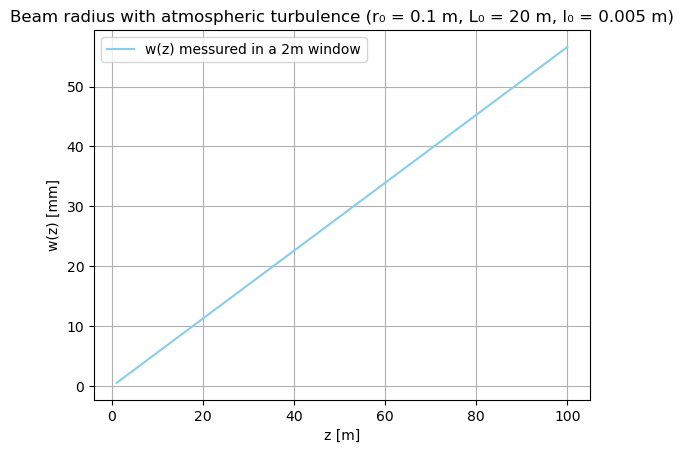

In [8]:
#turbolenz nur ein

wavelength= 980* 1e-9 #m
w0=2.92*1e-6 #hier erst einmal nur einfach
r0= 0.1 #10-20 cm
L0= 20 #m äußere Skalen der Turbulenz
l0= 0.005 #m innere Skalen der Turbulenz

z_values=np.array([1, 5, 10,20, 25, 50, 75, 100])
z_lin=np.linspace(1, 100, 1000)
w_values=[]

N = 2048 #512x 512 pixel
delta = 1e-3   #2 µm pro Pixe
x= (np.arange(N)-N/2)*delta
X,Y =np.meshgrid(x,x)

phase=ft_phase_screen(r0, N, delta, L0, l0) #Kolmogorov‑Statistik

U=np.exp(-(X**2+Y**2)/w0**2)
U_turb=U*np.exp(1j*phase)
I=np.abs(U_turb)**2

def w_eff(I, X,Y, delta): #nach ISO 11146
    R2=X**2+ Y**2
    P = np.sum(I) * delta * delta
    m2 = np.sum(I * R2) * delta * delta / P
    return np.sqrt(2*m2)

def propagate(U, wavelength, delta, z):
  #propagation with turbolences via angular spectrum of the disturbance
  fx=np.fft.fftfreq(U.shape[0], delta)
  FX, FY=np.meshgrid(fx,fx)
  k=2*np.pi/ wavelength
  H = np.exp(1j * k * z * np.sqrt(1 - (wavelength*FX)**2 - (wavelength*FY)**2))
  U_fft=np.fft.fft2(U)
  U_z=np.fft.ifft2(U_fft*H)
  return U_z

for z in z_lin:
  U_turb_z=propagate(U_turb, wavelength, delta,z )
  I_turb_z=np.abs(U_turb_z)**2
  w_eff_z=w_eff(I_turb_z, X,Y, delta)
  w_values.append(w_eff_z)

w_values_mm=1000*np.array(w_values)
plt.plot(z_lin, w_values_mm, color='skyblue', label='w(z) messured in a 2m window')
plt.title(f"Beam radius with atmospheric turbulence (r₀ = {r0} m, L₀ = {L0} m, l₀ = {l0} m)")
plt.xlabel("z [m]")
plt.ylabel("w(z) [mm]")
plt.grid()
plt.legend()
plt.show()